# Autoscaling configurations for publication

In [1]:
# Basic imports
%matplotlib widget
from numpy import mean  
from ascal import AscalConfig, Ascal
from examples import aws_eu_west_1_c5m5r5
import csv
import random

In [2]:
from math import sqrt

def sqrt_noise(x):
    delta = int(round(0.2*sqrt(x)))
    noise = random.randint(-delta, delta)
    return noise

def linear_noise(x):
    delta = int(round(0.1*x))
    noise = random.randint(-delta, delta)
    return noise

def generate_trace_file(file="trace.txt", duration=24*60, offset=0, ramp_up=0.25, plateau=0.5, 
                        ramp_down=0.25, start_value=1, end_value=10, noise=lambda x: 0):

    # Segment durations
    ramp_up = int(round(duration * ramp_up))
    plateau = int(round(duration * plateau))
    ramp_down = int(round(duration * ramp_down))
    valley = duration - (ramp_up + plateau + ramp_down)
    assert valley >= 0, "Duration too short for the given ramp/plateau proportions"

    def add_noise(value):
        return value + noise(value)

    values = []

    # Initial valley
    initial_valley = valley // 2
    for _ in range(initial_valley):
        noisy = add_noise(start_value)
        values.append(noisy)

    # Ramp up
    for i in range(ramp_up):
        base = start_value + (end_value - start_value) * i / (ramp_up - 1)
        noisy = add_noise(round(base))
        values.append(noisy)

    # Plateau
    for _ in range(plateau):
        noisy = add_noise(end_value)
        values.append(noisy)

    # Ramp down
    for i in range(ramp_down):
        base = end_value - (end_value - start_value) * i / (ramp_down - 1)
        noisy = add_noise(round(base))
        values.append(noisy)

    # Final valley
    for _ in range(valley - initial_valley):
        noisy = add_noise(start_value)
        values.append(noisy)

    # Save CSV
    values = values[-offset:] + values[:-offset]  # Apply offset
    with open(file, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["value"])
        for v in values:
            writer.writerow([v])


In [ ]:
# Configuration files defining ASCAL problems
config_files = [
    "config_hpa_ca.yaml", 
    "config_fcma_reactive.yaml", 
    "config_fcma_predictive.yaml",
    "config_hpa_ca_fcma_reactive.yaml",
    "config_hpa_ca_fcma_predictive.yaml"
    ]
config_files_1h = [
    "config_hpa_ca_1h.yaml", 
    "config_fcma_reactive_1h.yaml", 
    "config_fcma_predictive_1h.yaml",
    "config_hpa_ca_fcma_reactive_1h.yaml",
    "config_hpa_ca_fcma_predictive_1h.yaml"
]
log_file = None

In [ ]:
# Generate the trace files
random.seed(0)
generate_trace_file(file="trapezoid1.csv", duration=24*60, offset=0, ramp_up=0.25, plateau=0.3, 
                    ramp_down=0.25, start_value=1, end_value=10, noise=sqrt_noise)
generate_trace_file(file="trapezoid2.csv", duration=24*60, offset=100, ramp_up=0.4, plateau=0.4, 
                    ramp_down=0.2, start_value=2, end_value=20, noise=sqrt_noise)
generate_trace_file(file="triangle1.csv", duration=1*60, offset=0, ramp_up=0.5, plateau=0, 
                    ramp_down=0.5, start_value=1, end_value=10, noise=sqrt_noise)
generate_trace_file(file="triangle2.csv", duration=1*60, offset=100, ramp_up=0.4, plateau=0.4, 
                    ramp_down=0.2, start_value=2, end_value=20, noise=sqrt_noise)

'random.seed(0)\ngenerate_trace_file(file="trapezoid1.csv", duration=24*60, offset=0, ramp_up=0.25, plateau=0.3, \n                    ramp_down=0.25, start_value=1, end_value=10, noise=sqrt_noise)\ngenerate_trace_file(file="trapezoid2.csv", duration=24*60, offset=100, ramp_up=0.4, plateau=0.4, \n                    ramp_down=0.2, start_value=2, end_value=20, noise=sqrt_noise)\ngenerate_trace_file(file="triangle1.csv", duration=1*60, offset=0, ramp_up=0.5, plateau=0, \n                    ramp_down=0.5, start_value=1, end_value=10, noise=sqrt_noise)\ngenerate_trace_file(file="triangle2.csv", duration=1*60, offset=100, ramp_up=0.4, plateau=0.4, \n                    ramp_down=0.2, start_value=2, end_value=20, noise=sqrt_noise)'

Time range of the simulation: 0 - 86399 seconds
Time: 0 s
Time: 100 s
Time: 200 s
Time: 300 s
Time: 400 s
Time: 500 s
Time: 600 s
Time: 700 s
Time: 800 s
Time: 900 s
Time: 1000 s
Time: 1100 s
Time: 1200 s
Time: 1300 s
Time: 1400 s
Time: 1500 s
Time: 1600 s
Time: 1700 s
Time: 1800 s
Time: 1900 s
Time: 2000 s
Time: 2100 s
Time: 2200 s
Time: 2300 s
Time: 2400 s
Time: 2500 s
Time: 2600 s
Time: 2700 s
Time: 2800 s
Time: 2900 s
Time: 3000 s
Time: 3100 s
Time: 3200 s
Time: 3300 s
Time: 3400 s
Time: 3500 s
Time: 3600 s
Time: 3700 s
Time: 3800 s
Time: 3900 s
Time: 4000 s
Time: 4100 s
Time: 4200 s
Time: 4300 s
Time: 4400 s
Time: 4500 s
Time: 4600 s
Time: 4700 s
Time: 4800 s
Time: 4900 s
Time: 5000 s
Time: 5100 s
Time: 5200 s
Time: 5300 s
Time: 5400 s
Time: 5500 s
Time: 5600 s
Time: 5700 s
Time: 5800 s
Time: 5900 s
Time: 6000 s
Time: 6100 s
Time: 6200 s
Time: 6300 s
Time: 6400 s
Time: 6500 s
Time: 6600 s
Time: 6700 s
Time: 6800 s
Time: 6900 s
Time: 7000 s
Time: 7100 s
Time: 7200 s
Time: 7300 s
Ti

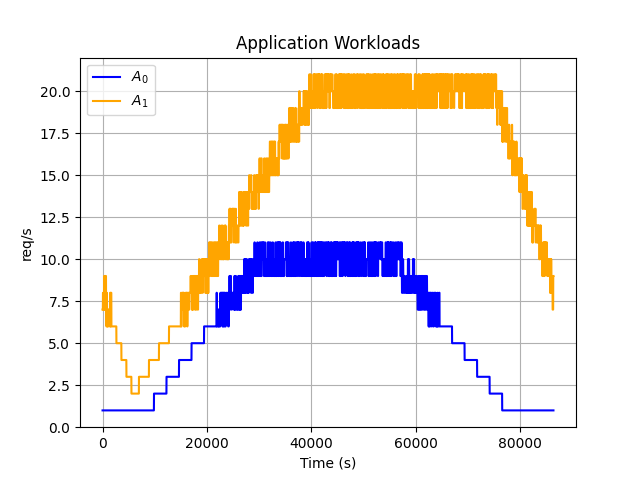

-----------------------------------------------------------------
Plotting results for configuration file: config_hpa_ca.yaml
-----------------------------------------------------------------


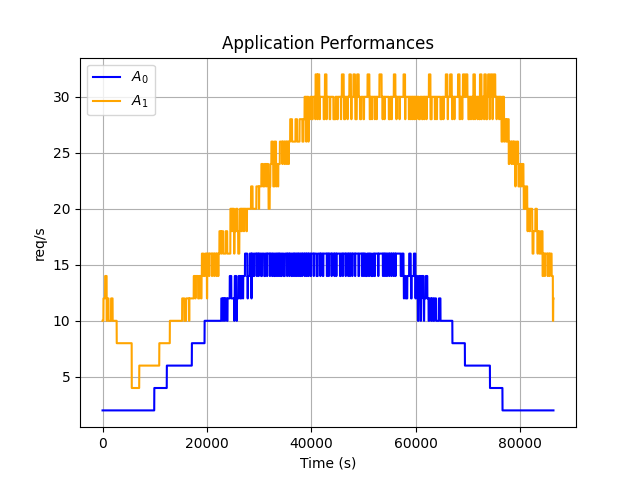

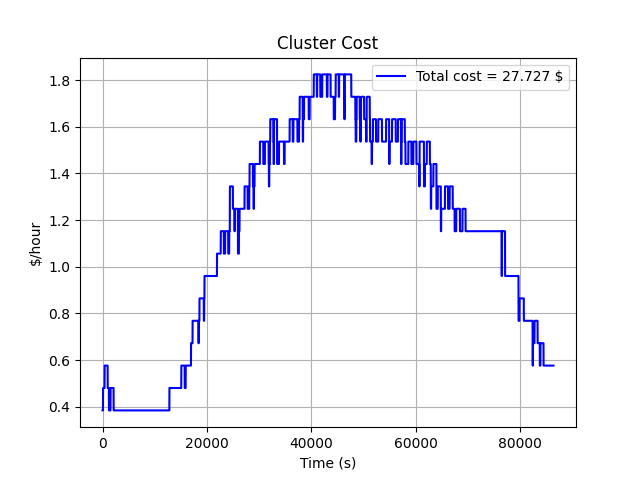

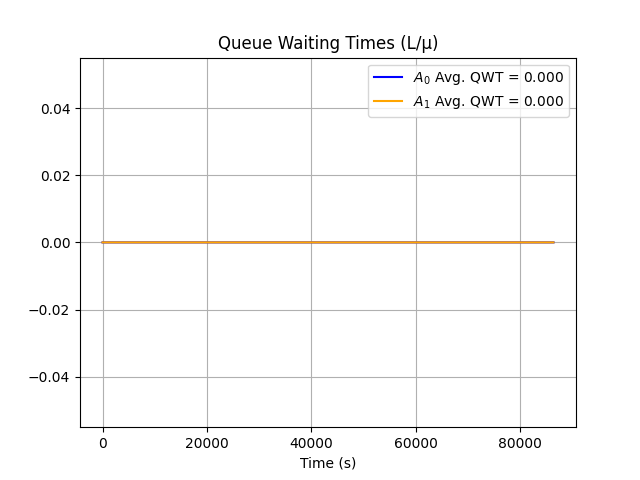

Time range of the simulation: 0 - 86399 seconds
Time: 0 s
You can check the CBC log at /tmp/810858c12af346f3ae762648338236bc-pulp.lp.log
You can check the CBC log at /tmp/6330a569f0c141e0953eb9230f6d54ae-pulp.lp.log
Time: 100 s
You can check the CBC log at /tmp/ac4ee31f90d142f58504a6479e933004-pulp.lp.log
You can check the CBC log at /tmp/b133c02f8e7545bb9bb6b0b5654d2457-pulp.lp.log
Time: 200 s
Time: 300 s
You can check the CBC log at /tmp/2e85d11be6254afb9b0f7dd4239d16c1-pulp.lp.log
You can check the CBC log at /tmp/1c2cd46e3a4f4d4f972e40ecd851becb-pulp.lp.log
Time: 400 s
You can check the CBC log at /tmp/7fa20c77c06645fc9a817ece6e26dfd0-pulp.lp.log
You can check the CBC log at /tmp/e2577052577045c688e35c6cbe2e47b0-pulp.lp.log
Time: 500 s
Time: 600 s
You can check the CBC log at /tmp/c8372d0aff0746a3aa15109cfc8b85d0-pulp.lp.log
You can check the CBC log at /tmp/6baafb76d5eb472ea38e1531689094d6-pulp.lp.log
Time: 700 s
You can check the CBC log at /tmp/fc991f1d4d0845388c774fec6187db50-p

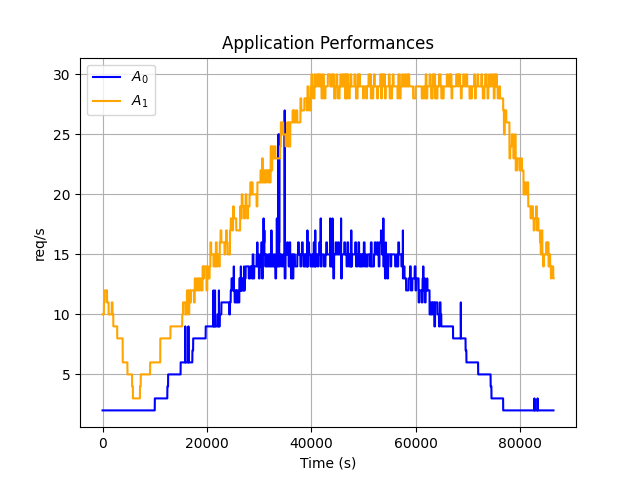

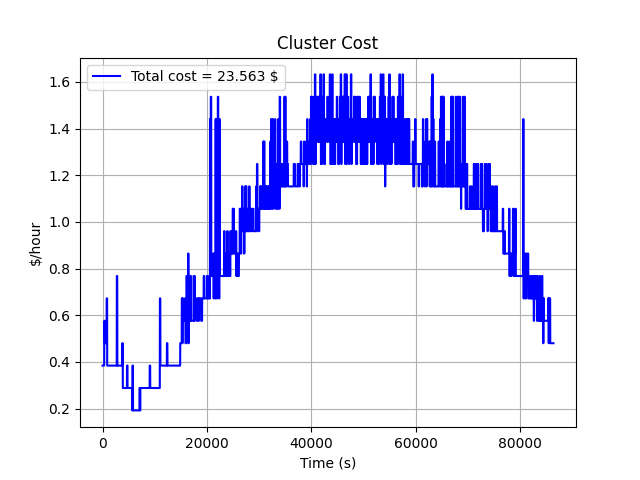

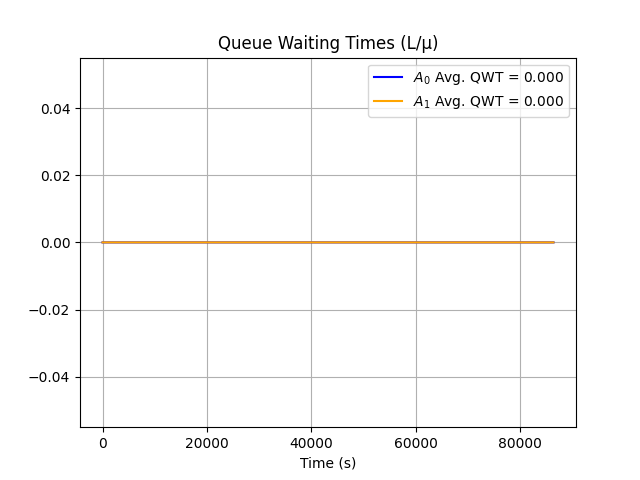

Time range of the simulation: 0 - 86399 seconds
Time: 0 s
You can check the CBC log at /tmp/23b28556999a4f348b7952d0982cab4e-pulp.lp.log
You can check the CBC log at /tmp/88a70c75a9ac4a06b3a5005a8cdf4efc-pulp.lp.log
You can check the CBC log at /tmp/8b09a4e3c8be4e14a83f2471ce111784-pulp.lp.log
You can check the CBC log at /tmp/c1053a9c1e3e425bb873ac3ef0095893-pulp.lp.log
You can check the CBC log at /tmp/6974aa79ca024a65bed59e569218a276-pulp.lp.log
You can check the CBC log at /tmp/be1c8da46ece47f0a173037722d96dd7-pulp.lp.log
Time: 100 s
Time: 200 s
Time: 300 s
You can check the CBC log at /tmp/e3a855ef342943f284b602a67505c3d4-pulp.lp.log
You can check the CBC log at /tmp/30ed3c31ff3841688c24561c701e45a9-pulp.lp.log
You can check the CBC log at /tmp/732fda0fc1e844169b6adb5ab11ff345-pulp.lp.log
You can check the CBC log at /tmp/961b5665e4494d6692fffce82857827f-pulp.lp.log
Time: 400 s
Time: 500 s
Time: 600 s
You can check the CBC log at /tmp/93efb58da4c447278446badc19dc71b9-pulp.lp.log
Y

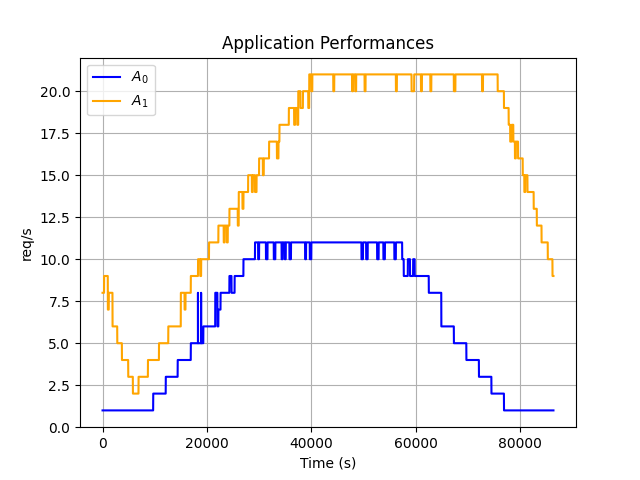

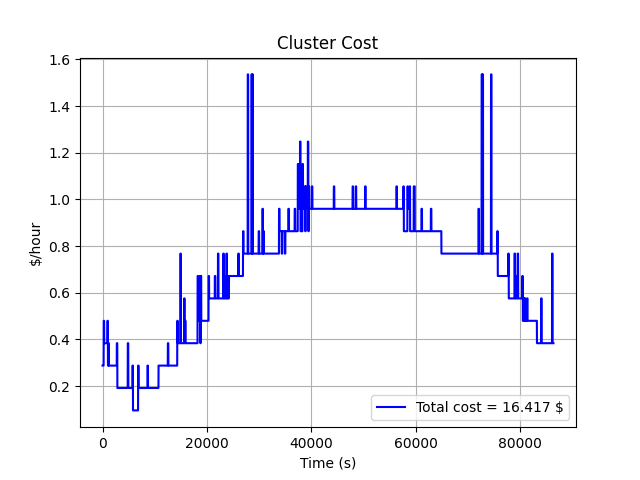

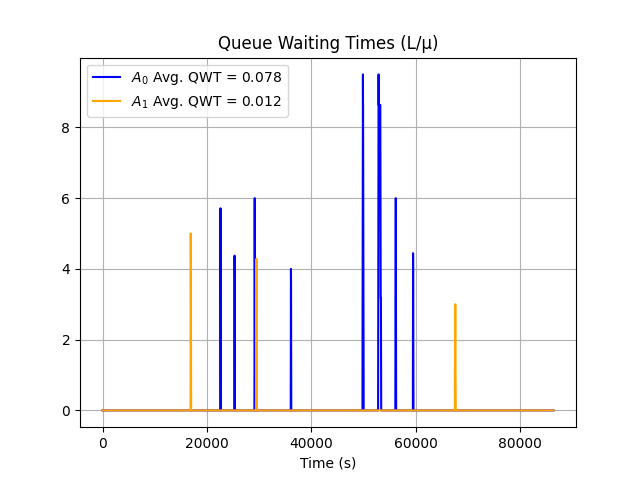

Time range of the simulation: 0 - 86399 seconds
Time: 0 s
Time: 100 s
Time: 200 s
Time: 300 s
Time: 400 s
Time: 500 s
Time: 600 s
You can check the CBC log at /tmp/f6e6c95fad5c441197a0e0c2f787bc44-pulp.lp.log
You can check the CBC log at /tmp/64019d183863445ab76d464eb506cb76-pulp.lp.log
Time: 700 s
Time: 800 s
Time: 900 s
Time: 1000 s
Time: 1100 s
Time: 1200 s
You can check the CBC log at /tmp/b5531056bed34b41b18b04504639677b-pulp.lp.log
You can check the CBC log at /tmp/46f8577dfd4542fa9ddcd901a1b19cb0-pulp.lp.log
Time: 1300 s
Time: 1400 s
Time: 1500 s
Time: 1600 s
Time: 1700 s
Time: 1800 s
You can check the CBC log at /tmp/73444f403fa645e3a272b5319cc84296-pulp.lp.log
You can check the CBC log at /tmp/f535bcfb760f405b8555bd6fa136538c-pulp.lp.log
Time: 1900 s
Time: 2000 s
Time: 2100 s
Time: 2200 s
Time: 2300 s
Time: 2400 s
You can check the CBC log at /tmp/4af5e7ed9e2e4bd1b70ba3298284f3ed-pulp.lp.log
You can check the CBC log at /tmp/7c411c873ac94368b542e52436430a38-pulp.lp.log
Time: 2

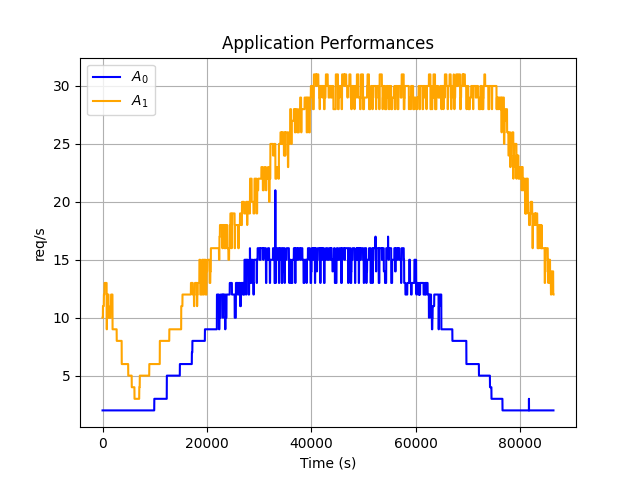

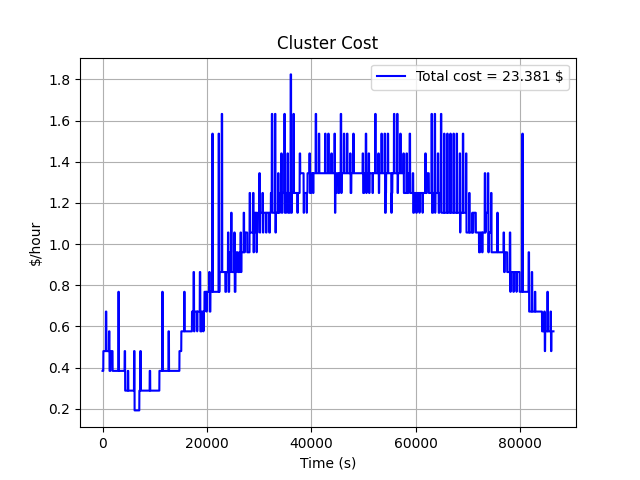

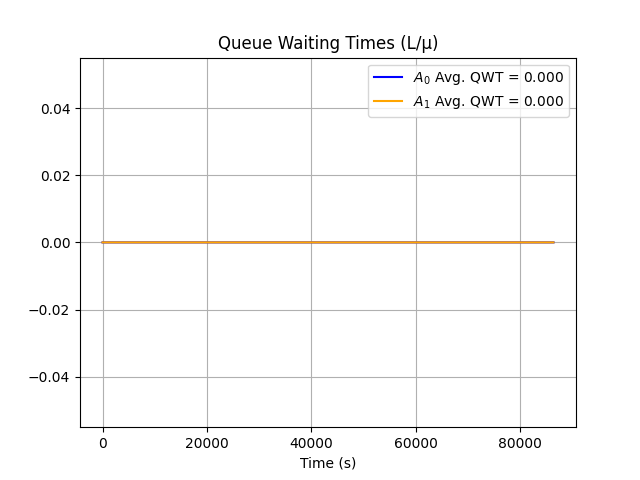

Time range of the simulation: 0 - 86399 seconds
Time: 0 s
Time: 100 s
Time: 200 s
Time: 300 s
Time: 400 s
You can check the CBC log at /tmp/1bfb4200d70344adb95e87f596aea635-pulp.lp.log
You can check the CBC log at /tmp/2f4f22b020754ecd8b36b6239fd6c404-pulp.lp.log
You can check the CBC log at /tmp/5d0e98522c214092868a0083f709e887-pulp.lp.log
You can check the CBC log at /tmp/45a7f92f754c41f0a4c24cf0fba92311-pulp.lp.log
Time: 500 s
Time: 600 s
Time: 700 s
Time: 800 s
Time: 900 s
Time: 1000 s
You can check the CBC log at /tmp/cdd62f28585c4f6c9c7832c82e16e93b-pulp.lp.log
You can check the CBC log at /tmp/a1b1dec9412447f09f12b81977a650db-pulp.lp.log
You can check the CBC log at /tmp/977636204af24786b500ce7760a9330c-pulp.lp.log
You can check the CBC log at /tmp/1ae114b5fa874e149cd34c9ef4a61107-pulp.lp.log
Time: 1100 s
Time: 1200 s
Time: 1300 s
Time: 1400 s
Time: 1500 s
Time: 1600 s
You can check the CBC log at /tmp/27be5654ee2e4c758fe20b257bb06b0a-pulp.lp.log
You can check the CBC log at /tm

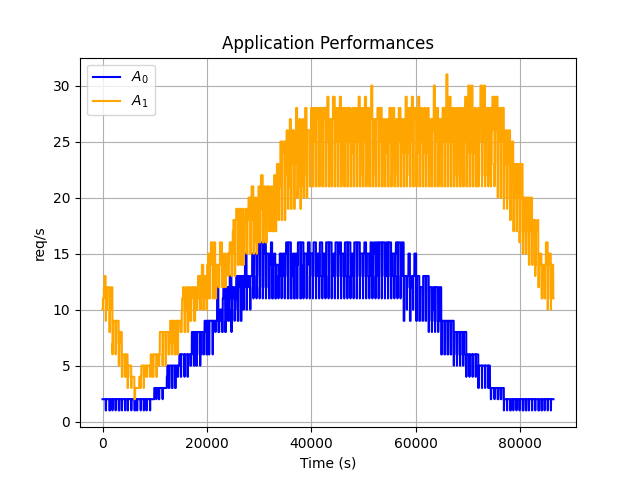

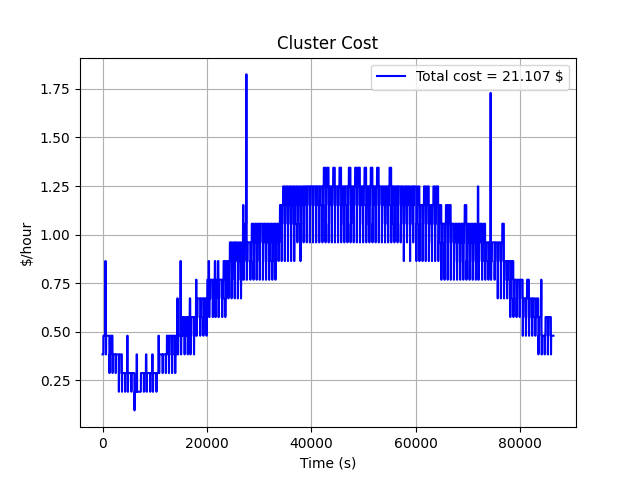

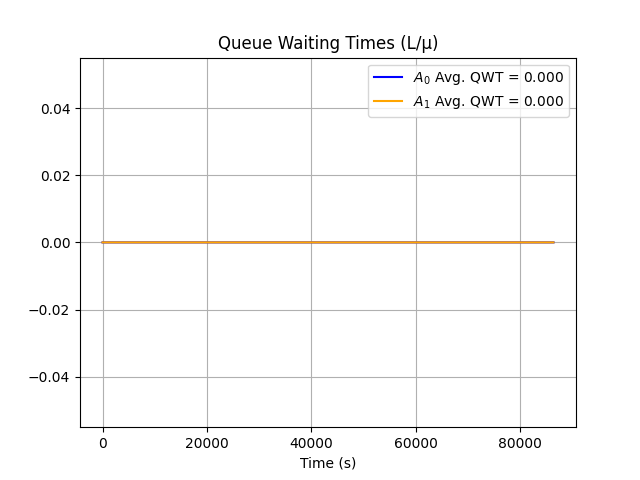

Time range of the simulation: 0 - 86399 seconds
Time: 0 s
Time: 100 s
Time: 200 s
Time: 300 s
Time: 400 s
Time: 500 s
Time: 600 s
You can check the CBC log at /tmp/5cf7ca01b7fd404ca4a52aef434a4a15-pulp.lp.log
You can check the CBC log at /tmp/779d550a06c842a08907069c6f6cab0c-pulp.lp.log
Time: 700 s
Time: 800 s
Time: 900 s
Time: 1000 s
Time: 1100 s
Time: 1200 s
You can check the CBC log at /tmp/04f03e81fba44b748965e3c4a5aef6aa-pulp.lp.log
You can check the CBC log at /tmp/029d68bff6d84045932a86427b449e3e-pulp.lp.log
Time: 1300 s
Time: 1400 s
Time: 1500 s
Time: 1600 s
Time: 1700 s
Time: 1800 s
You can check the CBC log at /tmp/9ed4512a45314ca9b842dd58b8f3f1bc-pulp.lp.log
You can check the CBC log at /tmp/2aaf2b073fa942219df8cae691cc7f5f-pulp.lp.log
Time: 1900 s
Time: 2000 s
Time: 2100 s
Time: 2200 s
Time: 2300 s
Time: 2400 s
You can check the CBC log at /tmp/26e1ca49e7784ba19b490d56aec85bcf-pulp.lp.log
You can check the CBC log at /tmp/e5579a4391d24f3aafb3bcde73140e6a-pulp.lp.log
Time: 2

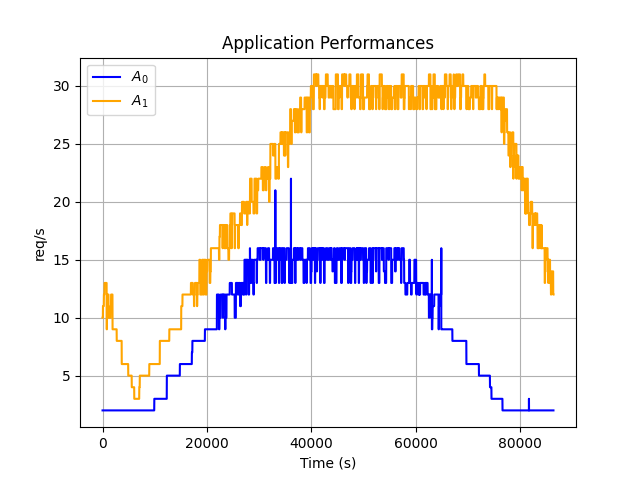

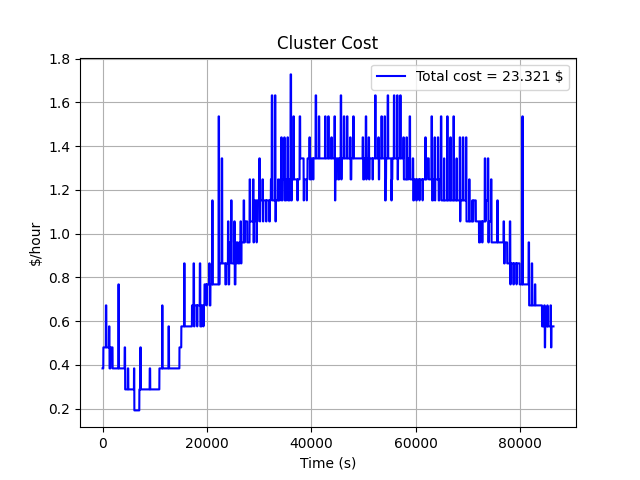

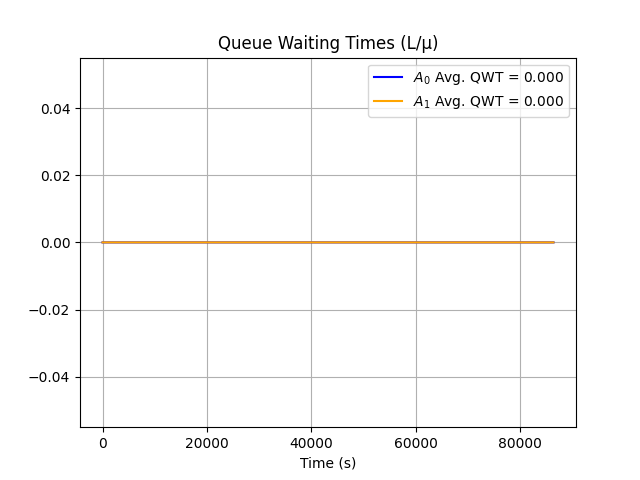

Time range of the simulation: 0 - 86399 seconds
Time: 0 s
Time: 100 s
Time: 200 s
Time: 300 s
Time: 400 s
You can check the CBC log at /tmp/1d3c4310254e48c38220e4a778ee269c-pulp.lp.log
You can check the CBC log at /tmp/9c018ae22bab421eb14a0716f3de762e-pulp.lp.log
You can check the CBC log at /tmp/8b4c3372f40043cfbd591073a2a47046-pulp.lp.log
You can check the CBC log at /tmp/0a50bfda9c894d608d10e0e671d26075-pulp.lp.log
Time: 500 s
Time: 600 s
Time: 700 s
Time: 800 s
Time: 900 s
Time: 1000 s
You can check the CBC log at /tmp/9267db7a33704561bbdc656c2b10422f-pulp.lp.log
You can check the CBC log at /tmp/cb15399547734b2a9a13fab23de96fc1-pulp.lp.log
You can check the CBC log at /tmp/09e69b2ec0b54f19ac59b3a2b7831e64-pulp.lp.log
You can check the CBC log at /tmp/770f99d8da194519a222bac5c884ffd1-pulp.lp.log
Time: 1100 s
Time: 1200 s
Time: 1300 s
Time: 1400 s
Time: 1500 s
Time: 1600 s
You can check the CBC log at /tmp/e781aa766dc04c598b6bb0f0e3b071c5-pulp.lp.log
You can check the CBC log at /tm

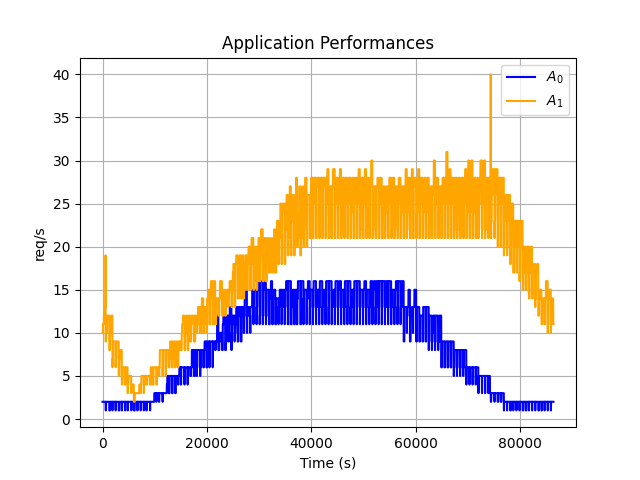

/home/chechu/ascal/ascal/ascal.py:730: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


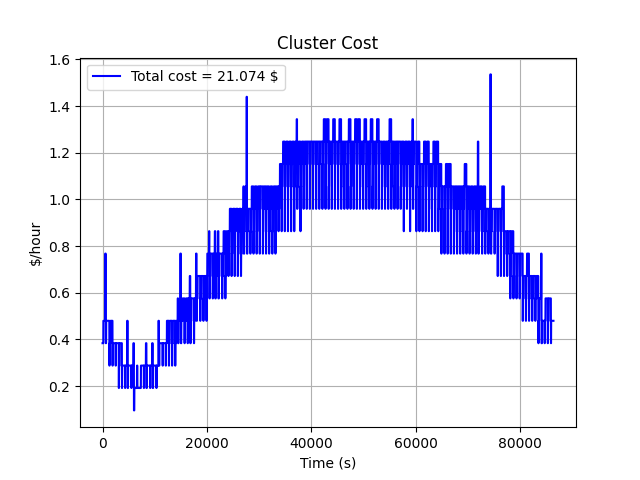

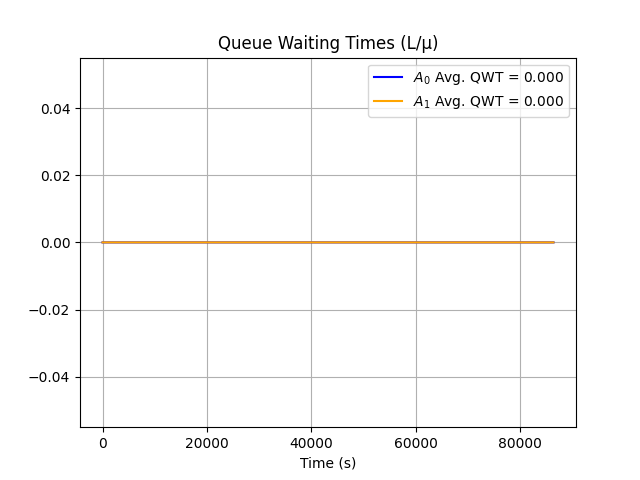

Time range of the simulation: 0 - 3599 seconds
Time: 0 s
Time: 100 s
Time: 200 s
Time: 300 s
Time: 400 s
Time: 500 s
Time: 600 s
Time: 700 s
Time: 800 s
Time: 900 s
Time: 1000 s
Time: 1100 s
Time: 1200 s
Time: 1300 s
Time: 1400 s
Time: 1500 s
Time: 1600 s
Time: 1700 s
Time: 1800 s
Time: 1900 s
Time: 2000 s
Time: 2100 s
Time: 2200 s
Time: 2300 s
Time: 2400 s
Time: 2500 s
Time: 2600 s
Time: 2700 s
Time: 2800 s
Time: 2900 s
Time: 3000 s
Time: 3100 s
Time: 3200 s
Time: 3300 s
Time: 3400 s
Time: 3500 s


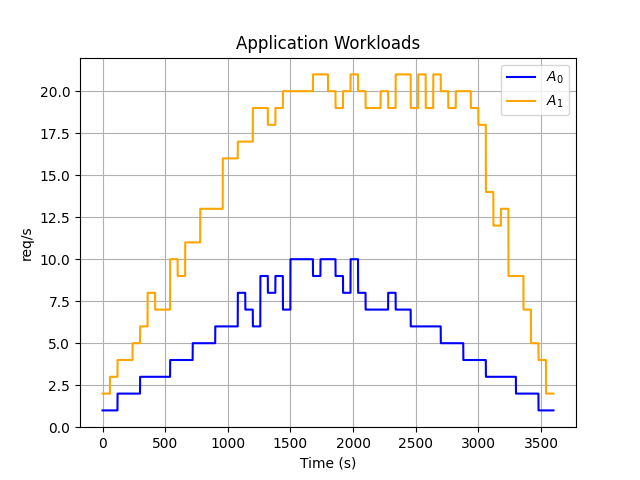

-----------------------------------------------------------------
Plotting results for configuration file: config_hpa_ca_1h.yaml
-----------------------------------------------------------------


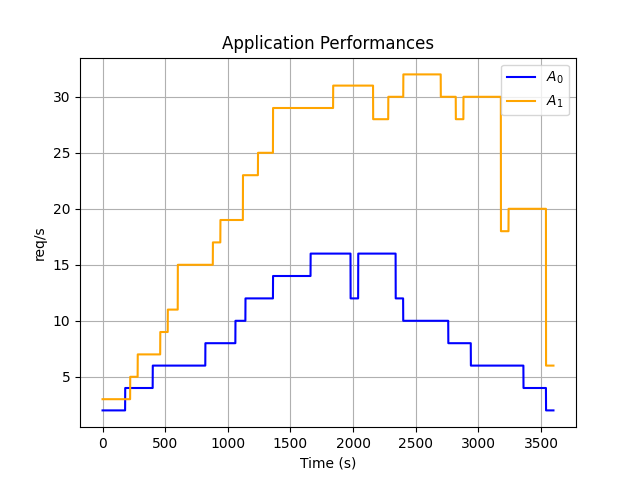

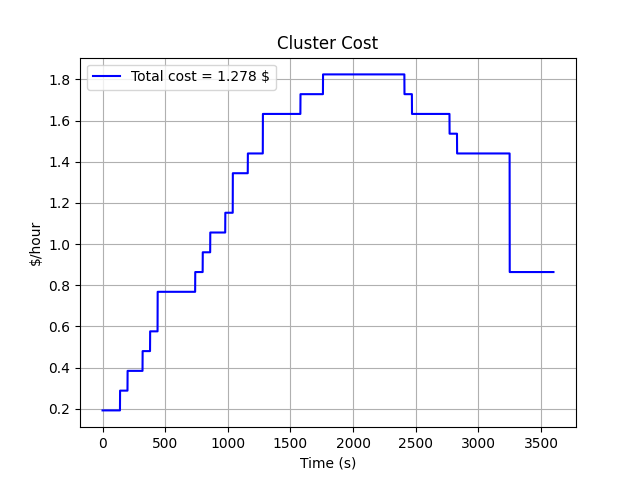

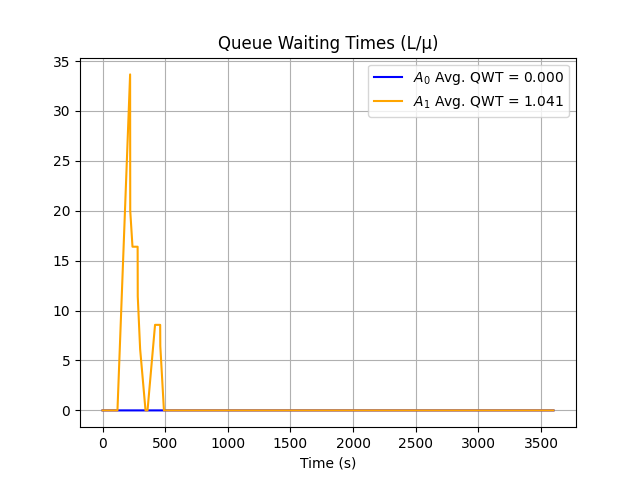

Time range of the simulation: 0 - 3599 seconds
Time: 0 s
You can check the CBC log at /tmp/fd259ce38a334837b65258fe6bd24e38-pulp.lp.log
You can check the CBC log at /tmp/3c84751b2df24043aa9d91a3ad1b91cf-pulp.lp.log
Time: 100 s
You can check the CBC log at /tmp/8527058d44de48eebf34dc588f701ed7-pulp.lp.log
You can check the CBC log at /tmp/b3085c673c644ba2a64b9bc4ad87d176-pulp.lp.log
Time: 200 s
Time: 300 s
You can check the CBC log at /tmp/39c4c86834064ce6816c10d9d4d4309d-pulp.lp.log
You can check the CBC log at /tmp/2199ac9d4f104aa2b7036355a7323254-pulp.lp.log
Time: 400 s
You can check the CBC log at /tmp/f4788634a5f84f9d902679cfa69a2018-pulp.lp.log
You can check the CBC log at /tmp/c9e9a1dabf8a492aa8bea02c57f29655-pulp.lp.log
Time: 500 s
Time: 600 s
You can check the CBC log at /tmp/ba7bf24aaf764a7f98ac74bc36eb1775-pulp.lp.log
You can check the CBC log at /tmp/9802a880ab384e2a80520631e57a3a0a-pulp.lp.log
Time: 700 s
You can check the CBC log at /tmp/311a5368d568404ab2f4e4d3a00aaaf9-pu

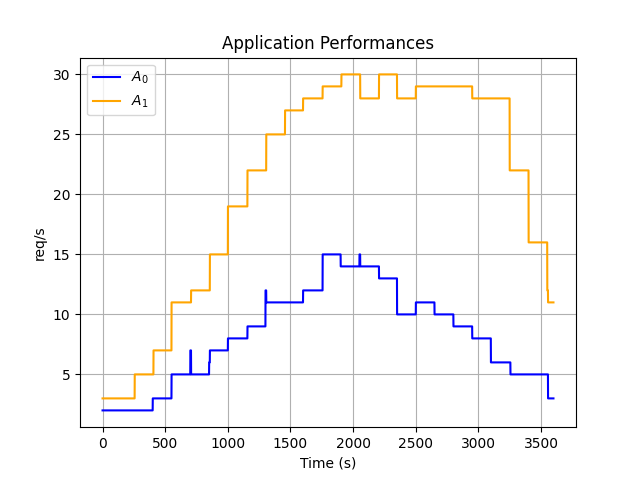

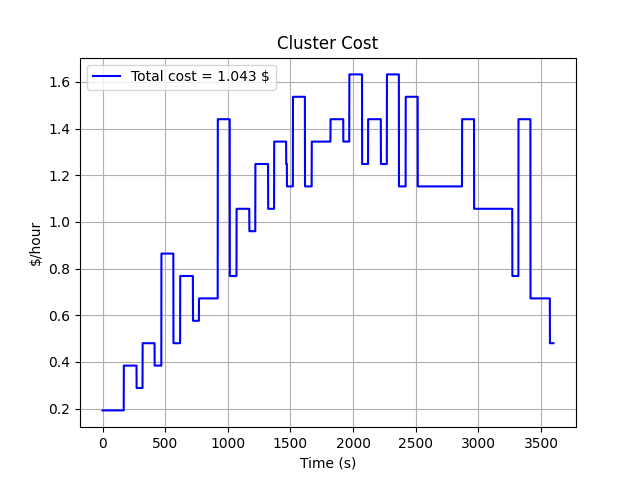

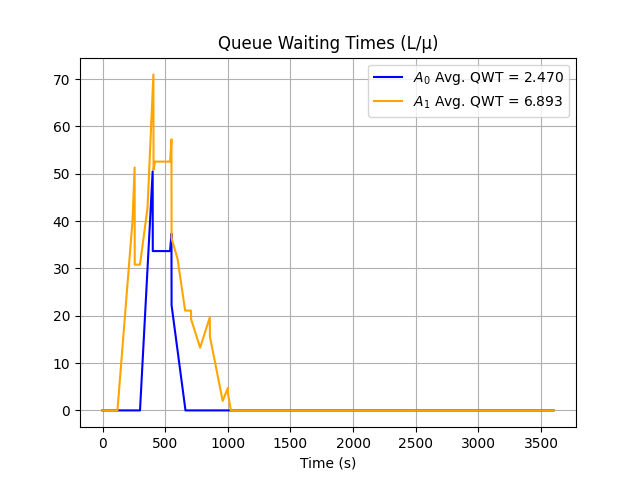

Time range of the simulation: 0 - 3599 seconds
Time: 0 s
You can check the CBC log at /tmp/791a5ad103dd4cba9224a77ca1107ed9-pulp.lp.log
You can check the CBC log at /tmp/f74d0c35b327451b829b01a234d9e0cf-pulp.lp.log
You can check the CBC log at /tmp/71bd1560790d482ab12eb75ba28a80d8-pulp.lp.log
You can check the CBC log at /tmp/87b30dc27d474db0b4512a1d1f141c4f-pulp.lp.log
You can check the CBC log at /tmp/090744ed2f734e57a6540045c81120b4-pulp.lp.log
You can check the CBC log at /tmp/0a2d68c158374389bedbec91d86b5f70-pulp.lp.log
Time: 100 s
Time: 200 s
Time: 300 s
You can check the CBC log at /tmp/fd02dea36fd048d88d6393d3eed8c3e0-pulp.lp.log
You can check the CBC log at /tmp/a2c654ec18444fbd904df1ec9a33c83e-pulp.lp.log
You can check the CBC log at /tmp/ebfecb23fe5d40df932486d466742836-pulp.lp.log
You can check the CBC log at /tmp/8fb5fbd0ccf44ee5b988ab26389264da-pulp.lp.log
Time: 400 s
Time: 500 s
Time: 600 s
You can check the CBC log at /tmp/4e4c3aa0cee04f8783ec0d7966789d3f-pulp.lp.log
Yo

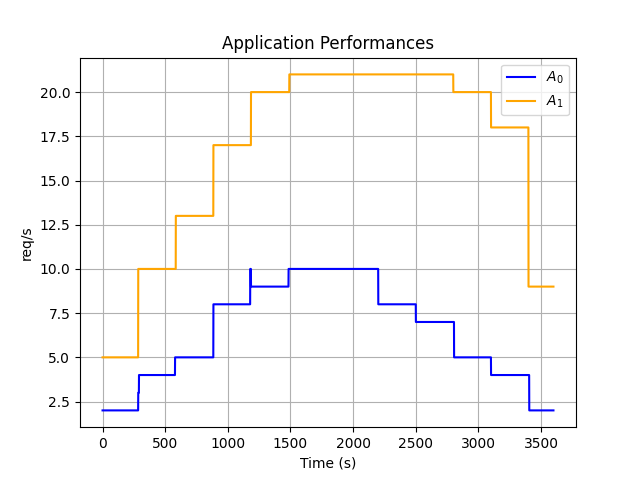

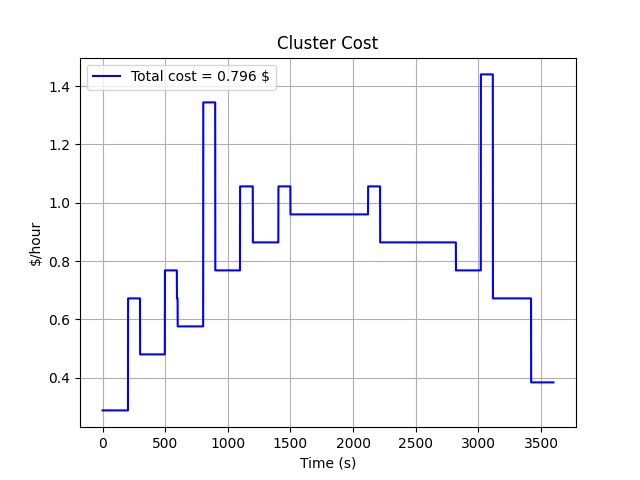

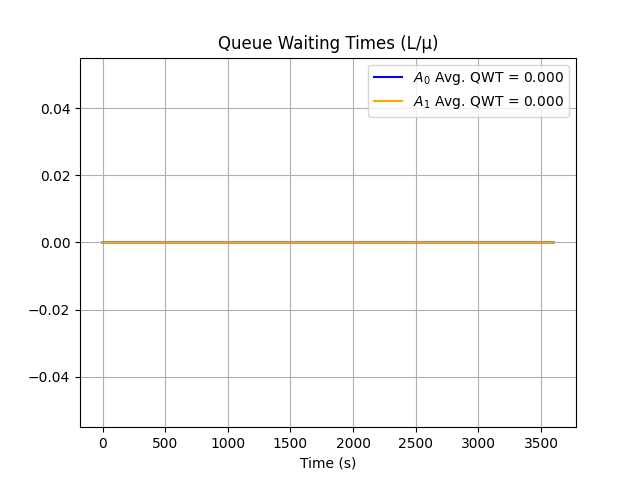

Time range of the simulation: 0 - 3599 seconds
Time: 0 s
Time: 100 s
Time: 200 s
Time: 300 s
Time: 400 s
Time: 500 s
Time: 600 s
You can check the CBC log at /tmp/5aa7b88562e840f2830c2a1f350a5366-pulp.lp.log
You can check the CBC log at /tmp/d346bb65bea341a291baefc0076443d6-pulp.lp.log
Time: 700 s
Time: 800 s
Time: 900 s
Time: 1000 s
Time: 1100 s
You can check the CBC log at /tmp/9003bad1206d41958dea19ca72120545-pulp.lp.log
You can check the CBC log at /tmp/a149c603e54a4d209718aba51559a69f-pulp.lp.log
Time: 1200 s
Time: 1300 s
Time: 1400 s
Time: 1500 s
Time: 1600 s
Time: 1700 s
Time: 1800 s
You can check the CBC log at /tmp/3120c774ff744324a81d9f492cd4fd20-pulp.lp.log
You can check the CBC log at /tmp/d1090af7c5ea4312b7f66817fc0aa5fd-pulp.lp.log
Time: 1900 s
Time: 2000 s
Time: 2100 s
Time: 2200 s
Time: 2300 s
Time: 2400 s
You can check the CBC log at /tmp/d3fa2c22f01444a7a8059a8b42838b78-pulp.lp.log
You can check the CBC log at /tmp/6b5e64c9a3ad48859d2078f894ec444e-pulp.lp.log
Time: 25

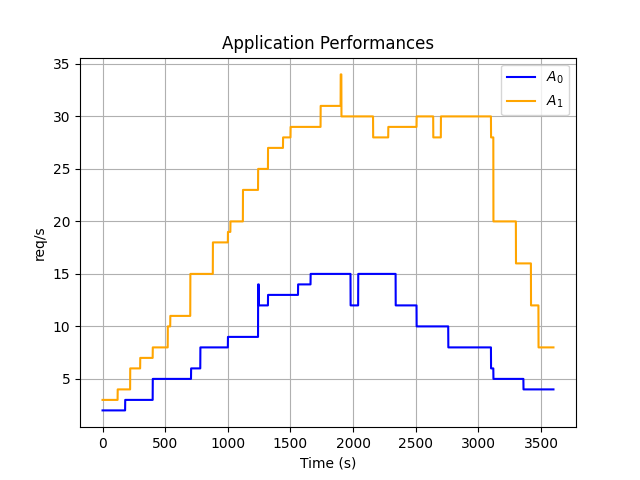

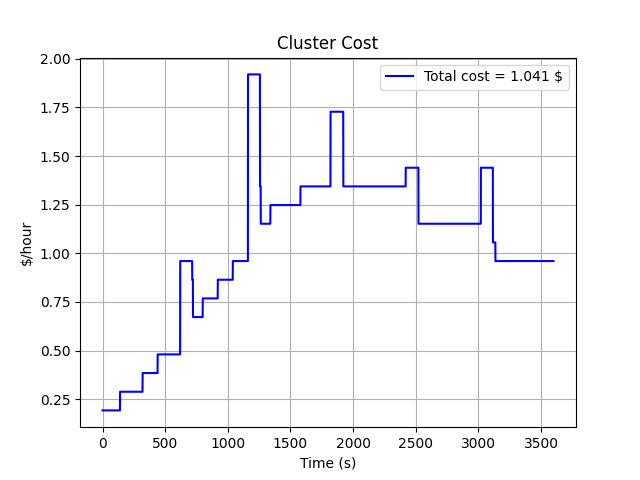

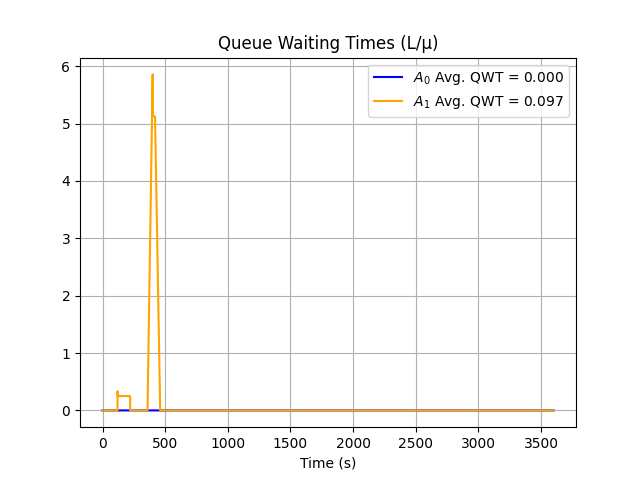

Time range of the simulation: 0 - 3599 seconds
Time: 0 s
Time: 100 s
Time: 200 s
Time: 300 s
Time: 400 s
You can check the CBC log at /tmp/253e2f670b4b41818aa18de982388c9c-pulp.lp.log
You can check the CBC log at /tmp/b0a8f7fda51f4480bb330d7a72503fb7-pulp.lp.log
You can check the CBC log at /tmp/458e18d158134bb5849c4132f95fd3e3-pulp.lp.log
You can check the CBC log at /tmp/8d32532a0c1943d287abda153261a499-pulp.lp.log
Time: 500 s
Time: 600 s
Time: 700 s
Time: 800 s
Time: 900 s
Time: 1000 s
You can check the CBC log at /tmp/016457c18ba94236854c9a9471d2dd9b-pulp.lp.log
You can check the CBC log at /tmp/68b34328bee1455e92e8d61d7295a211-pulp.lp.log
You can check the CBC log at /tmp/e75264548a44418e8fecd7c521790a33-pulp.lp.log
You can check the CBC log at /tmp/80d044b116f9440988452f57bf0465ca-pulp.lp.log
Time: 1100 s
Time: 1200 s
Time: 1300 s
Time: 1400 s
Time: 1500 s
Time: 1600 s
You can check the CBC log at /tmp/108541ecd04744b1aa4f206eda034d0c-pulp.lp.log
You can check the CBC log at /tmp

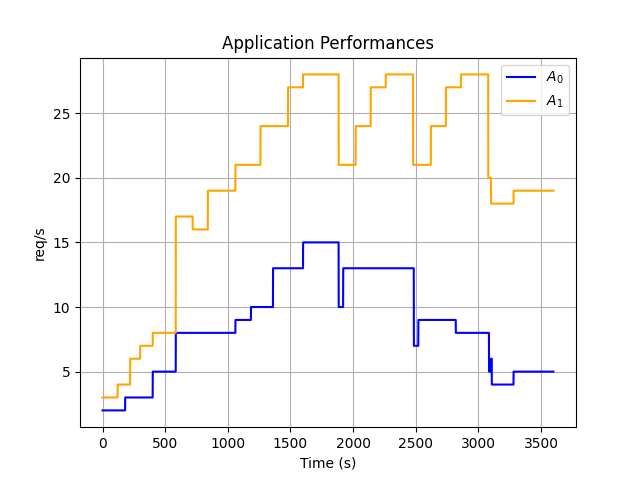

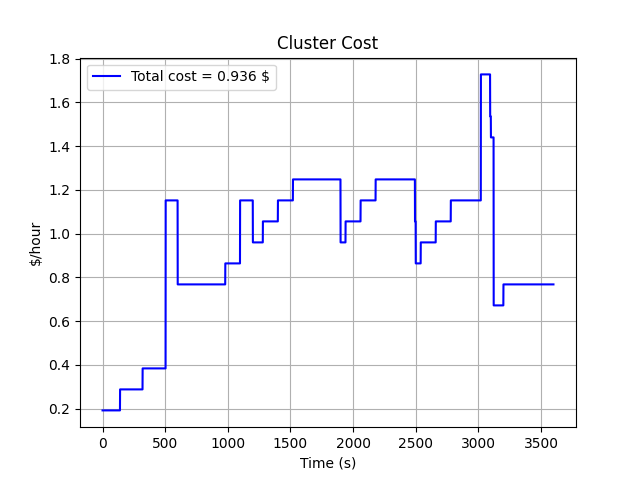

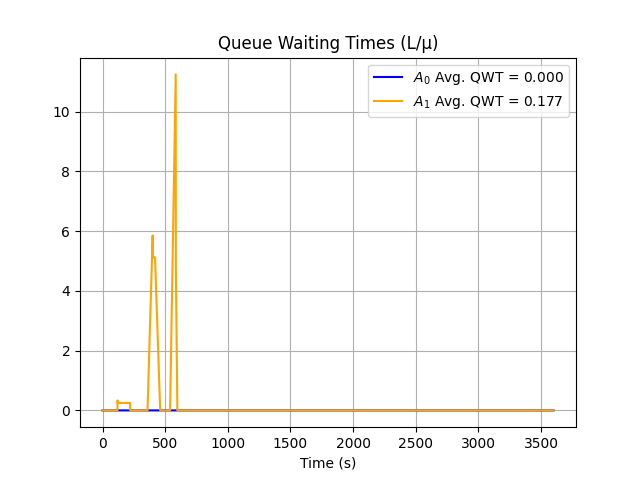

Time range of the simulation: 0 - 3599 seconds
Time: 0 s
Time: 100 s
Time: 200 s
Time: 300 s
Time: 400 s
Time: 500 s
Time: 600 s
You can check the CBC log at /tmp/8b52de926f94484ebc40a3368aea55f6-pulp.lp.log
You can check the CBC log at /tmp/264d4d3d45e6476f98f92ec58740f1e5-pulp.lp.log
Time: 700 s
Time: 800 s
Time: 900 s
Time: 1000 s
Time: 1100 s
You can check the CBC log at /tmp/51027588592a400bad49dfa2857cd203-pulp.lp.log
You can check the CBC log at /tmp/64d72f8391f14db98e443f8e0273e378-pulp.lp.log
Time: 1200 s
Time: 1300 s
Time: 1400 s
Time: 1500 s
Time: 1600 s
Time: 1700 s
Time: 1800 s
You can check the CBC log at /tmp/ffd2c921c1b04cd3994b8b592228b538-pulp.lp.log
You can check the CBC log at /tmp/934eaa300a3a48c5a7ec2280da4de18c-pulp.lp.log
Time: 1900 s
Time: 2000 s
Time: 2100 s
Time: 2200 s
Time: 2300 s
Time: 2400 s
You can check the CBC log at /tmp/04ef5aac1a3c45cb81da3933a76c5490-pulp.lp.log
You can check the CBC log at /tmp/ce9dd7de57d34e7fbd4ede141586985b-pulp.lp.log
Time: 25

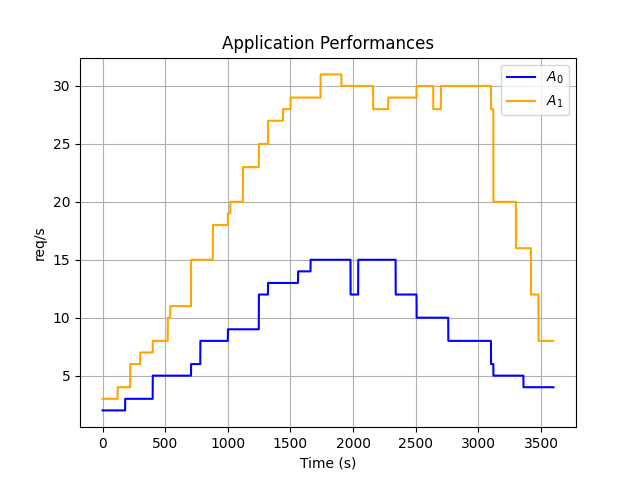

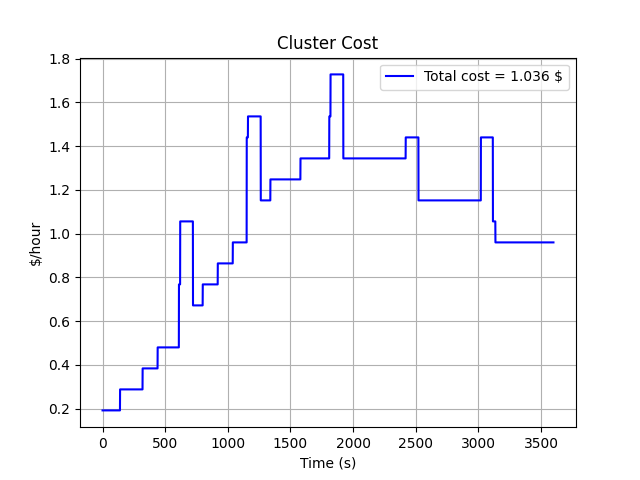

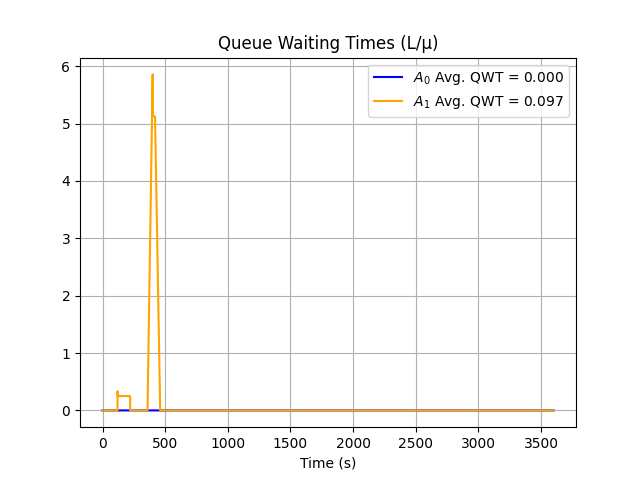

Time range of the simulation: 0 - 3599 seconds
Time: 0 s
Time: 100 s
Time: 200 s
Time: 300 s
Time: 400 s
You can check the CBC log at /tmp/bae679b3c08640a7babcf606e363d798-pulp.lp.log
You can check the CBC log at /tmp/71b61ca488854eaba185752041624200-pulp.lp.log
You can check the CBC log at /tmp/109f83beaf934efa9100e8b770082717-pulp.lp.log
You can check the CBC log at /tmp/10e0d9851873414fa9794267a391d7d8-pulp.lp.log
Time: 500 s
Time: 600 s
Time: 700 s
Time: 800 s
Time: 900 s
Time: 1000 s
You can check the CBC log at /tmp/c92ab6978e6a4477aabf6d1950805401-pulp.lp.log
You can check the CBC log at /tmp/81d41ee923394ae6b88adac368961271-pulp.lp.log
You can check the CBC log at /tmp/43b0ccc41809499b8e901838a9081d90-pulp.lp.log
You can check the CBC log at /tmp/269238411f2d4ff195e67e6f2a55d5e1-pulp.lp.log
Time: 1100 s
Time: 1200 s
Time: 1300 s
Time: 1400 s
Time: 1500 s
Time: 1600 s
You can check the CBC log at /tmp/c2ecbdad71bf433aa8bd8d82cb6ba110-pulp.lp.log
You can check the CBC log at /tmp

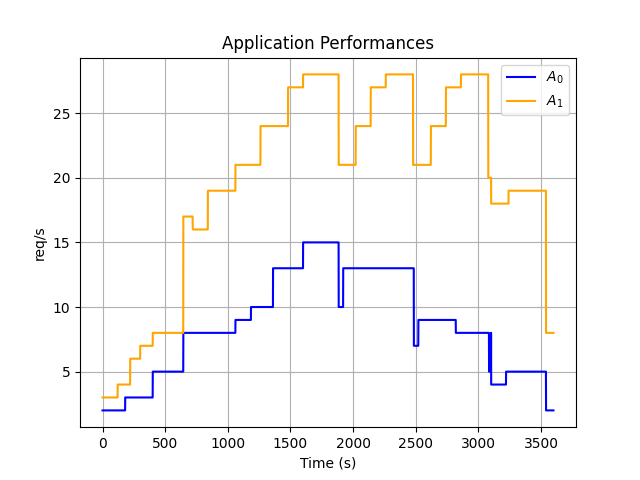

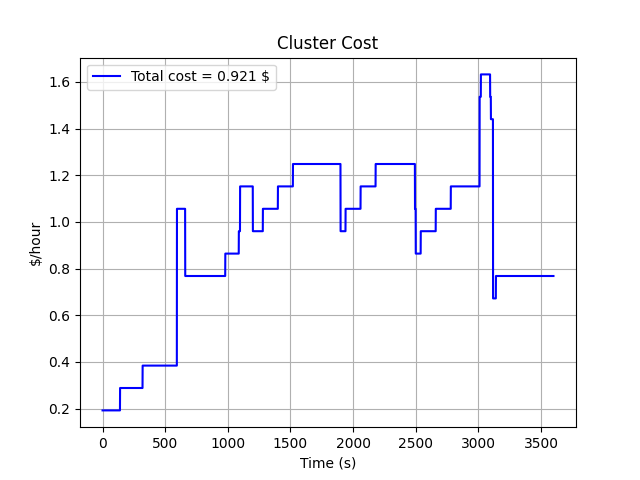

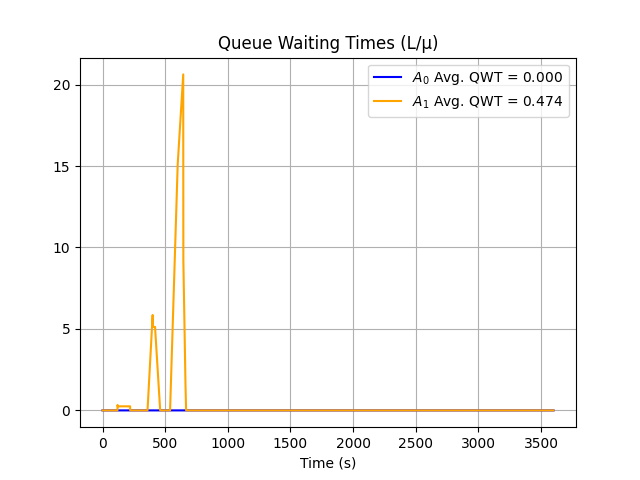

In [5]:
# Simulate each configuration file
for config_file in config_files + config_files_1h:  # Change to config_files to run all configurations
    # Read the problem configuration file and validate it
    # Note that it is possible to validate any ASCAL configuration with method AscalConfig.validate_config()
    ascal_config = AscalConfig.get_from_config_yaml(config_file, aws_eu_west_1_c5m5r5.c5_m5_r5_fm)

    # Create the autoscaling problem
    ascal_problem = Ascal(ascal_config, log=log_file)

    # Last time that can be simulated (last time in the trace)
    # Simulating time unit is seconds. Time starting from 0
    last_time = ascal_problem.last_time 
    print(f'Time range of the simulation: 0 - {last_time} seconds')

    # Run the autoscaling problem until the end. The argument of run() method is the last simulation time in seconds
    # Simulating time unit is seconds, so 3600 means 1 hour. Time starting from 0
    ascal_problem.run()

    # Get queue waiting times assuming each container is a server in an heterogenous D/D/m queue
    queue_waiting_times = ascal_problem.get_queue_waiting_times()
    avgs = {
        app_name: mean(waiting_times)
        for app_name, waiting_times in queue_waiting_times.items()
    }
    for app_name in dict(queue_waiting_times):
        queue_waiting_times[f"{app_name} Avg. QWT = {avgs[app_name]:.3f}"] = queue_waiting_times.pop(app_name)

    # Plot workloads
    if config_file == "config_hpa_ca.yaml" or config_file == "config_hpa_ca_1h.yaml":
        ascal_problem.plot(ascal_problem.get_workloads(), "Application Workloads", "req/s")

    # Plot autoscaling results
    print(f'-----------------------------------------------------------------')
    print(f'Plotting results for configuration file: {config_file}')
    print(f'-----------------------------------------------------------------')
    ascal_problem.plot(ascal_problem.get_performances(), "Application Performances", "req/s")
    cluster_cost = ascal_problem.get_cluster_cost()
    total_cost_str = f"Total cost = {sum(cluster_cost)/3600:.3f} $"
    ascal_problem.plot({total_cost_str: cluster_cost}, "Cluster Cost", "$/hour")
    ascal_problem.plot(queue_waiting_times, "Queue Waiting Times (L/μ)")